In [1]:
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_openai import ChatOpenAI

In [2]:
load_dotenv()

model = ChatOpenAI()

In [ ]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    evaluate: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    return {'outline': outline}

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    return {'content': content}

In [ ]:
def evaluate_blog(state: BlogState) -> BlogState:

    content = state['content']

    prompt = f'Evaluate the following blog and rate it out of 10 \n {content}'

    evaluate = model.invoke(prompt).content

    return {'evaluate': evaluate}

In [ ]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "evaluate_blog")
graph.add_edge("evaluate_blog", END)

workflow = graph.compile()

In [ ]:
initial_state= {'title': 'Rise of Ai in India'}
final_state = workflow.invoke(initial_state)
print(final_state['outline'])

In [ ]:
initial_state= {'title': 'Rise of Ai in India'}
final_state = workflow.invoke(initial_state)
print(final_state['content'])


In [ ]:
initial_state = {'title': 'Rise of Ai in India'}
final_state = workflow.invoke(initial_state)
print(final_state)
print(final_state.keys())
print(final_state['evaluate'])

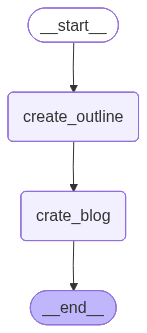

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
